In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from fit import fit
from torchinfo import summary
from mydataloader import my_dataloder
from lstm_2 import Lstm_2
from tqdm import trange
import os

In [2]:
folder_name = input('本次训练的数据源文件夹：')

本次训练的数据源文件夹：model10


In [3]:
path = '../trained_model/' + folder_name

In [4]:
xy_dict = np.load(path + '/train/xy_dict.npy', allow_pickle=True).item()

In [5]:
train_x = xy_dict['train_x'].astype(np.float32)
train_y = xy_dict['train_y'].astype(np.float32)
test_x = xy_dict['test_x'].astype(np.float32)
test_y = xy_dict['test_y'].astype(np.float32)

In [6]:
input_size = train_x.shape[-1]
print(input_size)

8


In [7]:
"""设置超参数"""
seq_len = 30
bs = 128
epochs = 100
hidden_size = 64
num_layers = 2

In [8]:
"""数据打包"""
train_dl, test_dl = my_dataloder(train_x, train_y, test_x, test_y, bs, shuffle=True)

In [9]:
"""设置模型参数"""
model = Lstm_2(train_x.shape[-1], hidden_size)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
summary(model, input_size=(bs, seq_len, input_size))

/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/torchinfo/torchinfo.py:477: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  action_fn=lambda data: sys.getsizeof(data.storage()),


Layer (type:depth-idx)                   Output Shape              Param #
Lstm_2                                   [128]                     51,712
├─Linear: 1-1                            [128, 1]                  65
Total params: 51,777
Trainable params: 51,777
Non-trainable params: 0
Total mult-adds (M): 0.01
Input size (MB): 0.12
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.12

In [11]:
"""训练"""
train_loss = []
test_loss = []
for epoch in trange(epochs):
    epoch_loss, epoch_test_loss = fit(epoch, model, train_dl, test_dl, loss_fn, optimizer)
    train_loss.append(epoch_loss)
    test_loss.append(epoch_test_loss)
print('Done!')

  1%|▍                                          | 1/100 [00:39<1:05:01, 39.41s/it]

epoch: 0 loss: 0.00278836 test_loss 3.489e-05


  2%|▊                                          | 2/100 [01:18<1:04:10, 39.29s/it]

epoch: 1 loss: 4.112e-05 test_loss 3.836e-05


  3%|█▎                                         | 3/100 [01:57<1:03:29, 39.27s/it]

...

epoch: 97 loss: 7.74e-06 test_loss 7.48e-06


 99%|█████████████████████████████████████████▌| 99/100 [1:05:53<00:40, 40.34s/it]

epoch: 98 loss: 7.53e-06 test_loss 6.55e-06


100%|█████████████████████████████████████████| 100/100 [1:06:33<00:00, 39.93s/it]

epoch: 99 loss: 7.66e-06 test_loss 1.046e-05
Done!


In [12]:
"""绘图"""
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['PingFang']

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: PingFang
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pyiwen/mambaforge/envs/nb/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) 

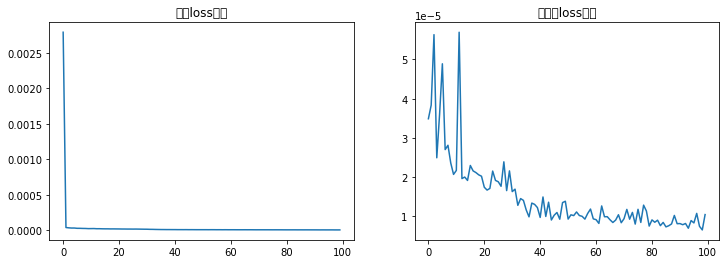

In [13]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.title('训练loss曲线')
plt.plot(train_loss)
plt.subplot(122)
plt.title('测试集loss曲线')
plt.plot(test_loss)
plt.show()

In [14]:
"""保存训练结果"""
torch.save(model, path + '/train/my_model.pth')

In [15]:
test_x_ts = torch.from_numpy(test_x).type(torch.float32)

In [16]:
y_pred = model(test_x_ts).detach().numpy()

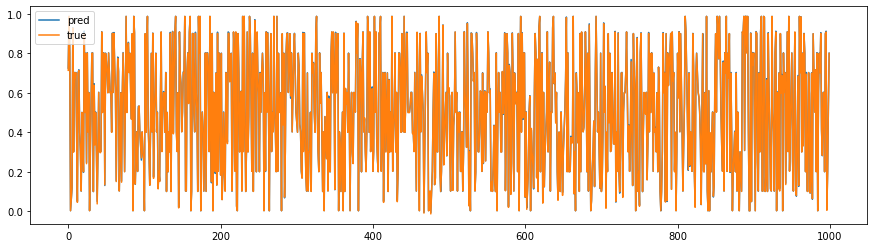

In [17]:
plt.figure(figsize=(15, 4))
plt.plot(y_pred[0:1000], label='pred')
plt.plot(test_y[0:1000], label='true')
plt.legend()
plt.show()

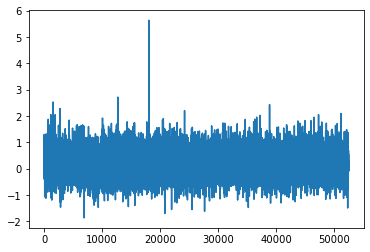

In [18]:
plt.plot((y_pred - test_y)*100)

In [19]:
test_x_ts

tensor([[[ 0.7270, -0.1388,  0.7252,  ...,  0.1357,  0.0941,  0.0977],
         [ 0.7270, -0.1389,  0.7250,  ...,  0.1357,  0.0941,  0.0977],
         [ 0.7222, -0.1388,  0.7248,  ...,  0.1357,  0.0941,  0.0977],
         ...,
         [ 0.7238, -0.1332,  0.7212,  ...,  0.1357,  0.0941,  0.0977],
         [ 0.7292, -0.1111,  0.7211,  ...,  0.1357,  0.0941,  0.0977],
         [ 0.7297, -0.1112,  0.7209,  ...,  0.1357,  0.0941,  0.0977]],

        [[ 0.9568,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000],
         [ 0.9557,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000],
         [ 0.9589,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000],
         ...,
         [ 0.9557,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000],
         [ 0.9578,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000],
         [ 0.9622,  0.0000,  0.9821,  ...,  0.1710,  0.0000,  0.0000]],

        [[ 0.8476,  0.0000,  0.8076,  ...,  0.1397,  0.0040,  0.0079],
         [ 0.8459,  0.0000,  0.8076,  ...,  0